# Community detection in complex networks

Basics:
* Communities are **locally dense connected subgraphs** in a network.
* Community detection aims to uncover the inherent community structure of a network.

Definitions:
* Clique - a fully connected subgraph within a larger graph.
* Strong community - each node has more edges connecting it to other nodes inside the group than to nodes outside the group.
* Weak community - the total internal degree of the group exceeds its total external degree.

Approaches and algorithms:
* Graph partitioning
* Hierarchical clustering (Girvan–Newman)
* Modularity optimization (Louvain)

## Introduction to community detection

Lets start with a simple example of a small graph.

In [49]:
import networkx as nx

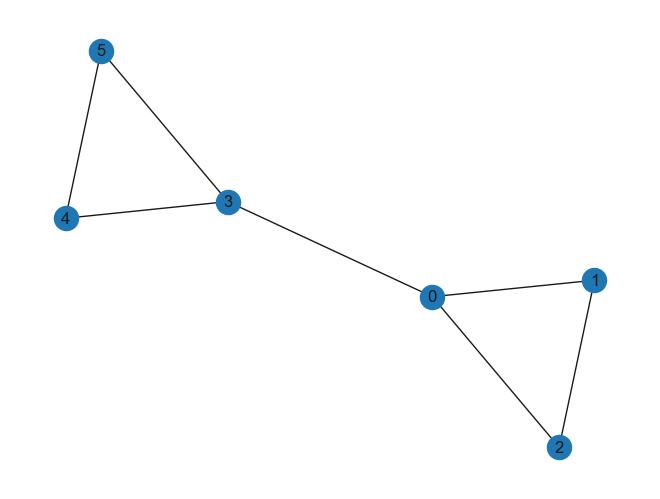

In [50]:
G = nx.Graph()
nx.add_cycle(G, [0, 1, 2])
nx.add_cycle(G, [3, 4, 5])
G.add_edge(0, 3)

nx.draw(G, with_labels=True)

How can we devide this graph into communities to get partitions of good quality? At first we'll do it by hand and validate if the partition is valid.

In [51]:
partition = [
    {0, 1, 2},
    {3, 4, 5},
]

nx.community.is_partition(G, partition)

True

Now, create a mapping between nodes and partitions, that will be of use for visualization and assesment of partition quality.

In [52]:
def create_node_to_partition_mapping(partition):
    node_to_partition = {}
    for idx, cluster_nodes in enumerate(partition):
        for node in cluster_nodes:
            node_to_partition[node] = idx
    return node_to_partition


node_to_partition = create_node_to_partition_mapping(partition)
node_to_partition

{0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1}

Then visualize this simple graph again with color of nodes corresponding to the partition they belong to.

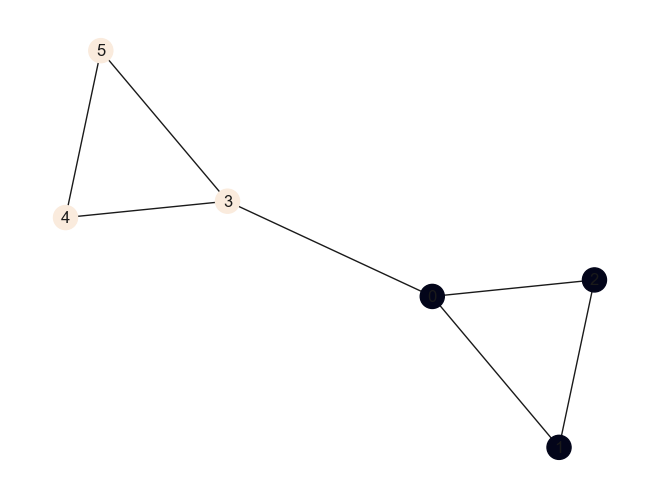

In [53]:
colors = [node_to_partition[n] for n in G.nodes]
nx.draw(G, node_color=colors, with_labels=True)

## Modularity

Now with the defined partition, we need to look for an answer to the question of can we evaluate the goodness of this network partition, and in a broader context, any partition of any graph?

One possible answer is to compare the connection density of the groups to a random baseline, as random networks do not have groups.

The modularity measure is defined as the difference between the number of internal links in the clusters and the expected number of links in a random network.

$$Q = \frac{1}{L}\sum_C(L_C - \frac{k_C^2}{4L})$$

where:
- $L$ - total number of links
- $L_c$ - number of links inside cluster $C$
- $\frac{k_C^2}{4L}$ - number of links in a random network

NetworkX comes with an efficient implementation of modularity calculation ```nx.community.quality.modularity(G, partition)```, that we will use to measure partition quality.

In [54]:
nx.community.quality.modularity(G, partition)

0.35714285714285715

We can verify how the modularity value change if we decide to change the partition.

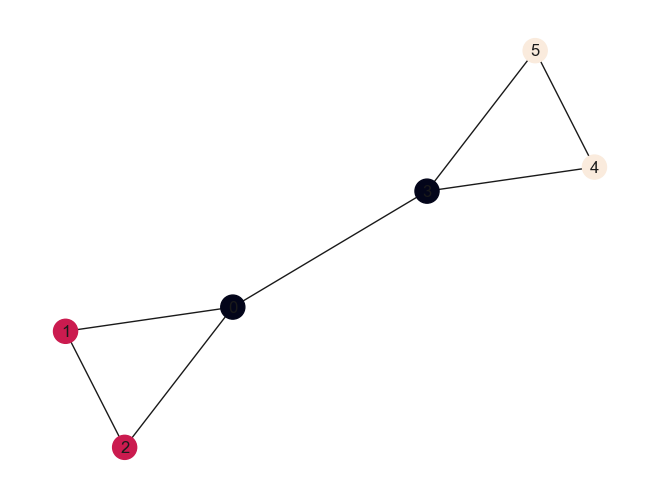

In [55]:
partition2 = [
    {0, 3},
    {1, 2},
    {4, 5},
]

colors = [create_node_to_partition_mapping(partition2)[n] for n in G.nodes]
nx.draw(G, node_color=colors, with_labels=True)

In [56]:
nx.community.quality.modularity(G, partition2)

0.0816326530612245

## Setting up networks for study

In the next sections of this notebook, we will be working with different networks, both artificial and real-world and algorithms that will help us identify communities within those networks.

In [57]:
connected_caveman_graph = nx.connected_caveman_graph(4, 8)
small_world_network = nx.watts_strogatz_graph(34, 4, 0.15)
windmill_graph = nx.windmill_graph(5, 7)
gaussian_random_partition_graph = nx.gaussian_random_partition_graph(
    n=34, s=9, v=9, p_in=0.7, p_out=0.03, seed=42
)
random_partition_graph = nx.random_partition_graph(
    [10, 8, 5, 5, 3, 3], 0.8, 0.04, seed=42
)
karate_club_network = nx.karate_club_graph()

### Task 1
The first task is to take a look at the networks that are going to be the subject of study. Prepare a visualization of the graphs defined in the previous cell. Place all of them on a single plot, remember to include subplot titles to be able to identify them and find the best positionig that helps to reveale the network structure.

#### Code

In [58]:
import matplotlib.pyplot as plt

In [59]:
graphs = {
    "Connected Caveman Graph": connected_caveman_graph,
    "Small World Network": small_world_network,
    "Windmill Graph": windmill_graph,
    "Gaussian Random Partition Graph": gaussian_random_partition_graph,
    "Random Partition Graph": random_partition_graph,
    "Karate Club Network": karate_club_network,
}

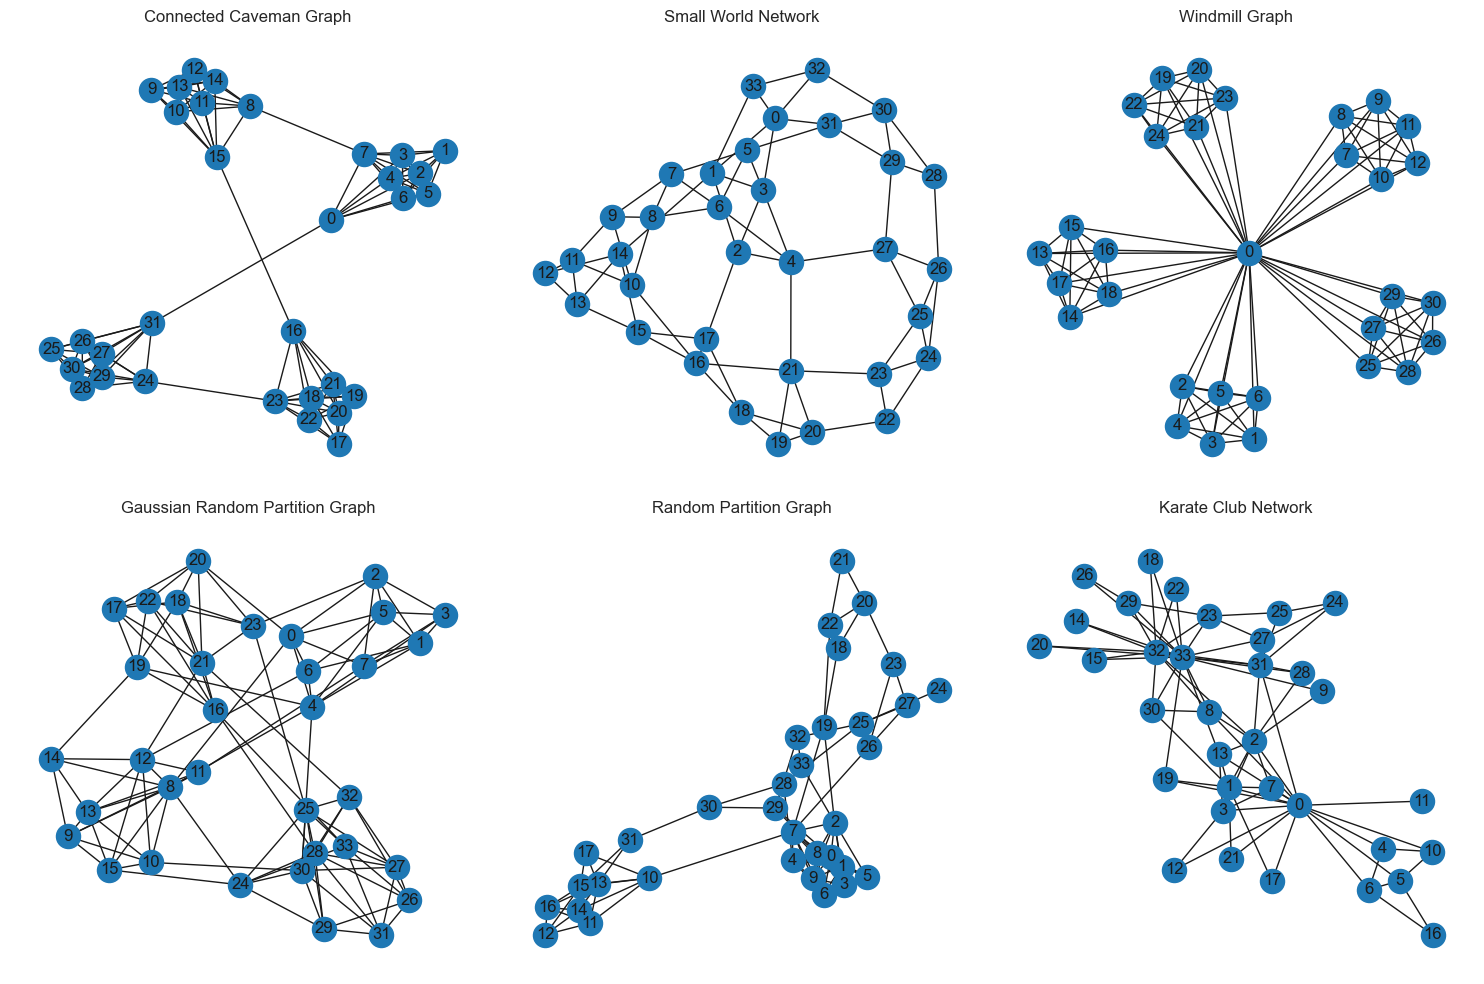

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (name, graph) in zip(axes.flatten(), graphs.items()):
    nx.draw(graph, ax=ax, with_labels=True)
    ax.set_title(name)
plt.tight_layout()
plt.show()

## Cliques identification

### Task 2
Calculate the number of different size cliques present in each network and visualize them on a barplot.

Analyse and interpret the obtained results, write your conclusions in the cell below. What does the number of cliques says about those networks? Are they differnt or quite similar?

#### Code

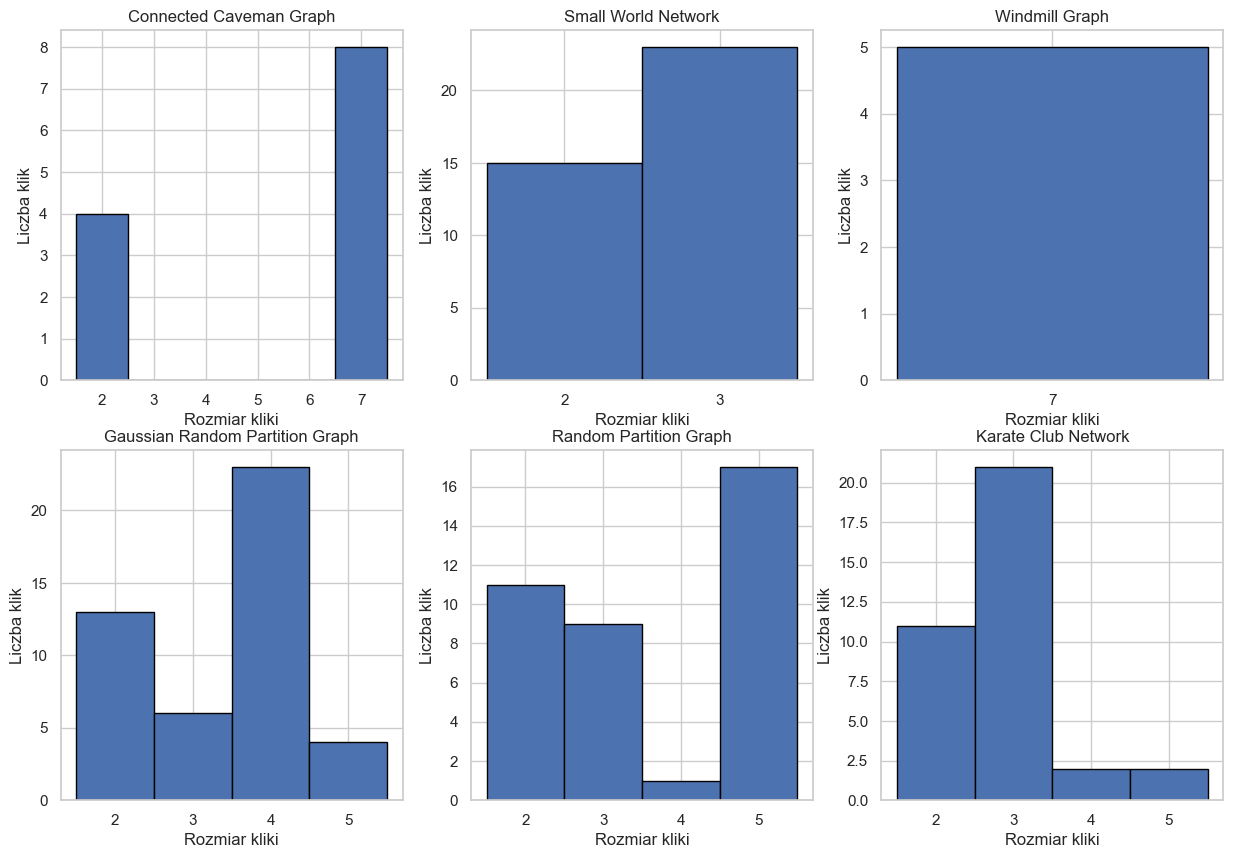

In [61]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (name, graph) in zip(axes.flatten(), graphs.items()):
    cliques = list(nx.find_cliques(graph))
    sizes = [len(clique) for clique in cliques]
    bins = range(min(sizes), max(sizes) + 2)
    ax.hist(sizes, bins=bins, align="left", edgecolor="black")
    ax.set_xticks(range(min(sizes), max(sizes) + 1))
    ax.set_title(name)
    ax.set_xlabel("Rozmiar kliki")
    ax.set_ylabel("Liczba klik")

#### Conclusions

- caveman posiada kilki male (2, laczniki grup) i duze (7, wewnetrzne grupy)
- small world tworzy co najwyzej trojkaty
- duze kliki (7), grupy polaczone przez wspolny centralny wezel
- sieci random-partition posiadaja kliki o roznych rozmiarach, roznice sa w rozkladach rozmiarow klik
- karate-club dominuja kliki o rozmiarze 2 i 3

## Hierarchical clustering using Girvan–Newman algorithm

The Girvan–Newman algorithm is a popular method for detecting communities in complex networks. It is based on the concept of edge betweenness centrality and operates by iteratively removing edges with the highest betweenness centrality. This process effectively breaks the network into smaller components, which can then be interpreted as communities.

The algorithm's steps
1. The betweenness of all existing edges in the network is calculated first.
2. The edge(s) with the highest betweenness are removed.
3. The betweenness of all edges affected by the removal is recalculated.
4. Steps 2 and 3 are repeated until no edges remain.

### Task 3
Use Girvan–Newman algorithm to detect communities among all studied networks. Use NetworkX function ```nx.algorithms.community.girvan_newman(G)```. Visualize and inspect obtained results for different numbers of communities. Find the best split for each network using modularity as a goodness measure and plot partitioned networks. Save the modularity results for each network for later comparison with other community detection method.

#### Code

In [62]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import modularity, girvan_newman

# Słownik na wyniki modułowości do późniejszego porównania

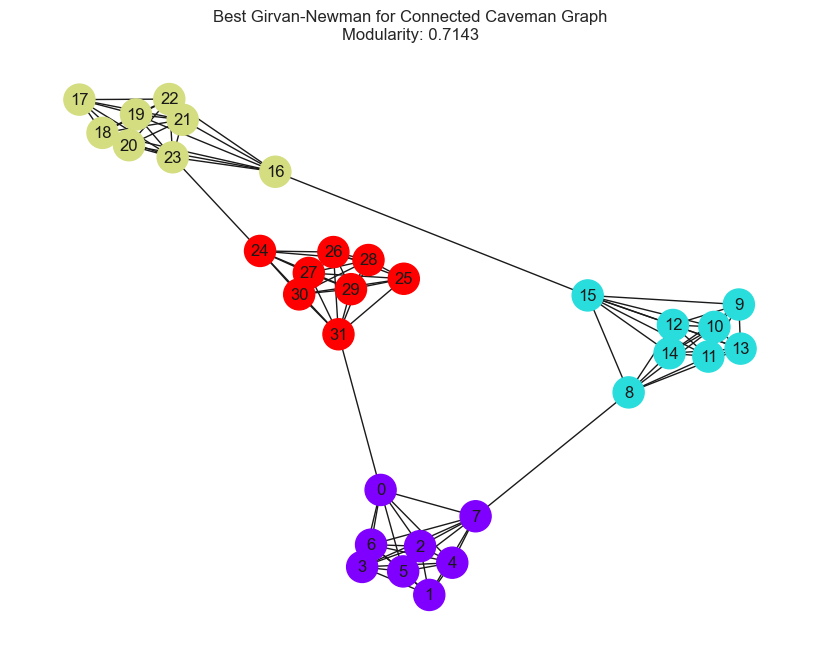

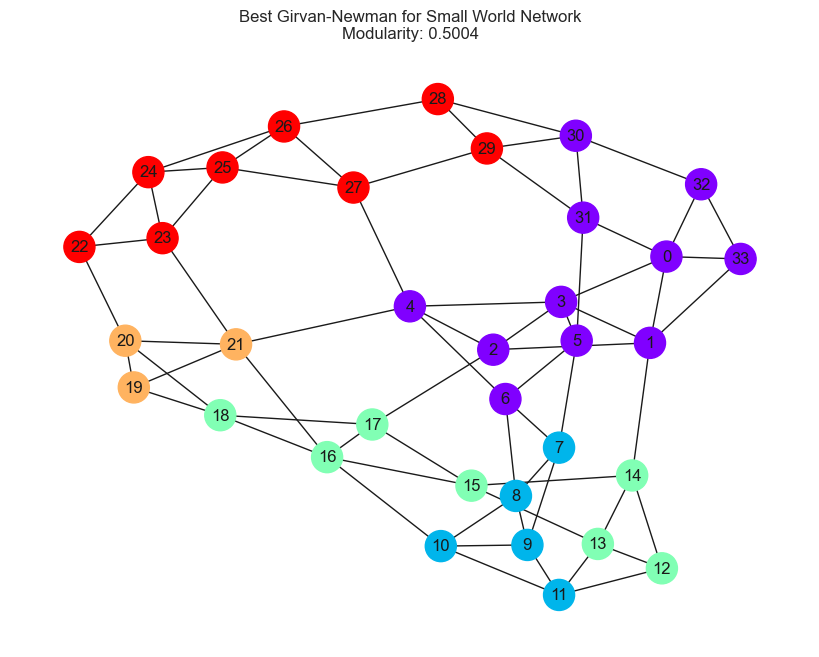

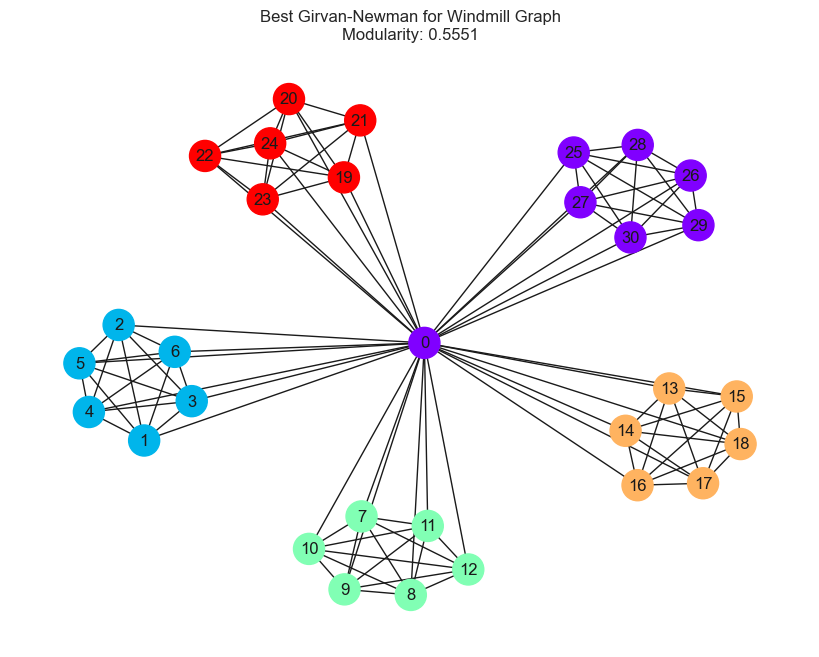

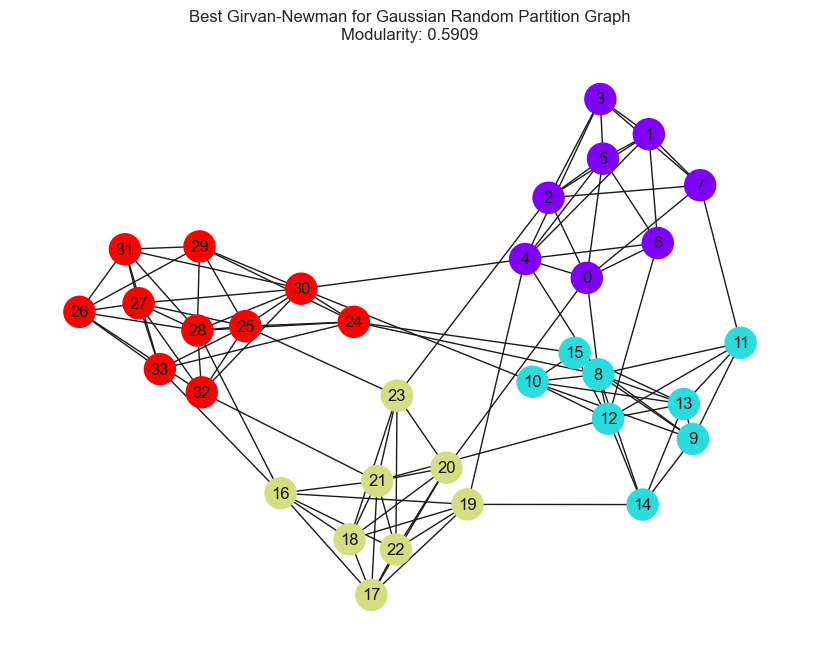

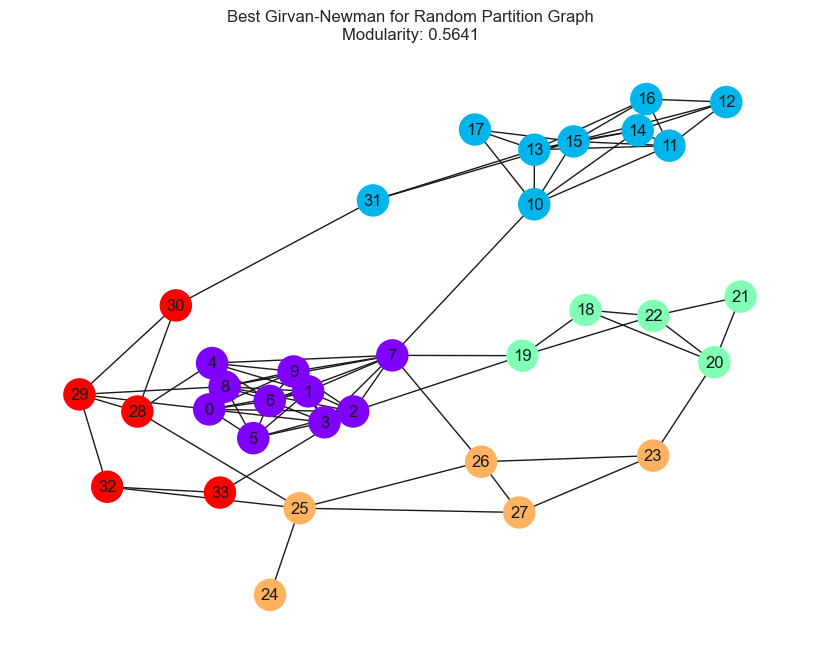

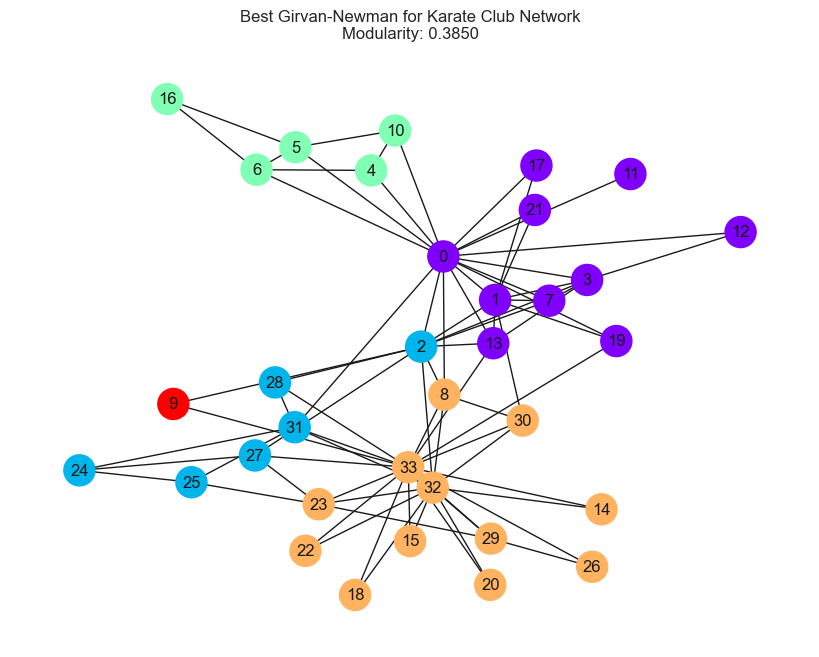

modularity_results: {'Connected Caveman Graph': 0.7142857142857143, 'Small World Network': 0.5004325259515571, 'Windmill Graph': 0.5551020408163265, 'Gaussian Random Partition Graph': 0.5909017125233341, 'Random Partition Graph': 0.5641333165004419, 'Karate Club Network': 0.3849721706864564}


In [63]:
modularity_results = {}

for name, graph in graphs.items():
    communities_generator = girvan_newman(graph)

    best_modularity = -1
    best_partition = None

    for i in range(min(graph.number_of_nodes() - 1, 15)):
        current_communities = next(communities_generator)
        current_modularity = modularity(graph, current_communities)

        if current_modularity > best_modularity:
            best_modularity = current_modularity
            best_partition = current_communities

    modularity_results[name] = best_modularity
    node_to_partition = create_node_to_partition_mapping(best_partition)

    colors = [node_to_partition[n] for n in graph.nodes]

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(graph)
    nx.draw(
        graph,
        pos,
        node_color=colors,
        with_labels=True,
        cmap=plt.cm.rainbow,
        node_size=500,
    )
    plt.title(f"Best Girvan-Newman for {name}\nModularity: {best_modularity:.4f}")
    plt.show()

print("modularity_results:", modularity_results)

## Modularity based community detection using Louvain algorithm
The Louvain algorithm is the most popular community detection algorithm. Its operation is based on the optimization of modularity. Louvain can be used even with very large networks with millions of nodes and edges.

### Louvain algorithm
1. Start with each node assigned to its own group.
2. Loop over nodes:

  2.1. Assign the node to the neighbor community that will give you the largest modularity increase.

  2.2. Repeat step 2.1 until no further modularity increase is possible.
3. Transform your network into a super network.

  3.1. Each community becomes a supernode.

  3.2. Assign weights to the edges corresponding to the number of connections within and between the groups.
4. Repeat step 2 until no further modularity increase is possible.


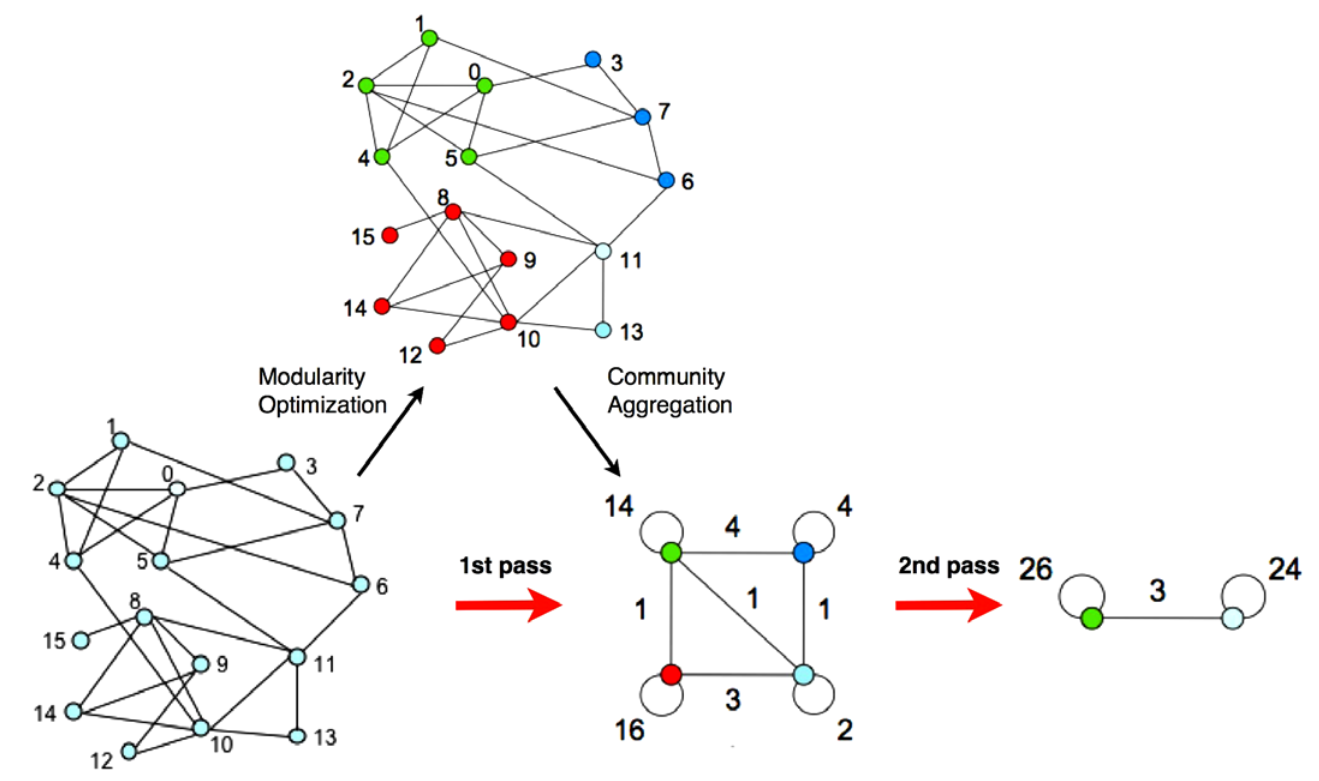

### Task 4
Use Louvain algorithm to detect communities among all studied networks. Use NetworkX function ```nx.community.louvain_communities(G, seed)```. Visualize and inspect the results.

Analyse and interpret the obtained communities, write your conclusions in the cell below.

 - Can we consider the produced split an optimal one? Change the seed value and check how it influences the obtained results, can you explain why the splits are sometimes different?

 - Compare the modularity value for generated partitions between Louvain algorithm and Girvan-Newmann algorithm. Which one is better in your opinion?

#### Code

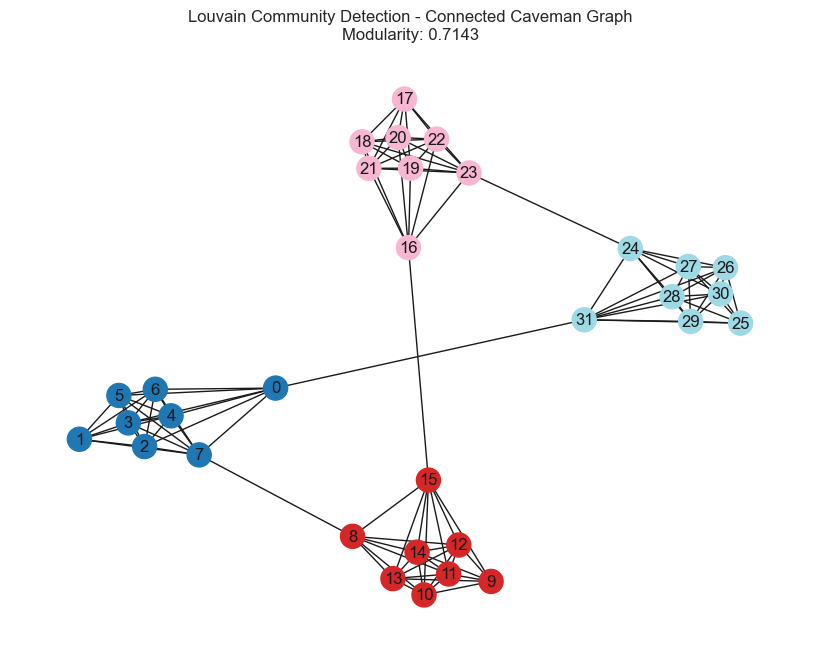

Network: Connected Caveman Graph
Louvain Modularity: 0.7143
Girvan-Newman Modularity: 0.7143
------------------------------


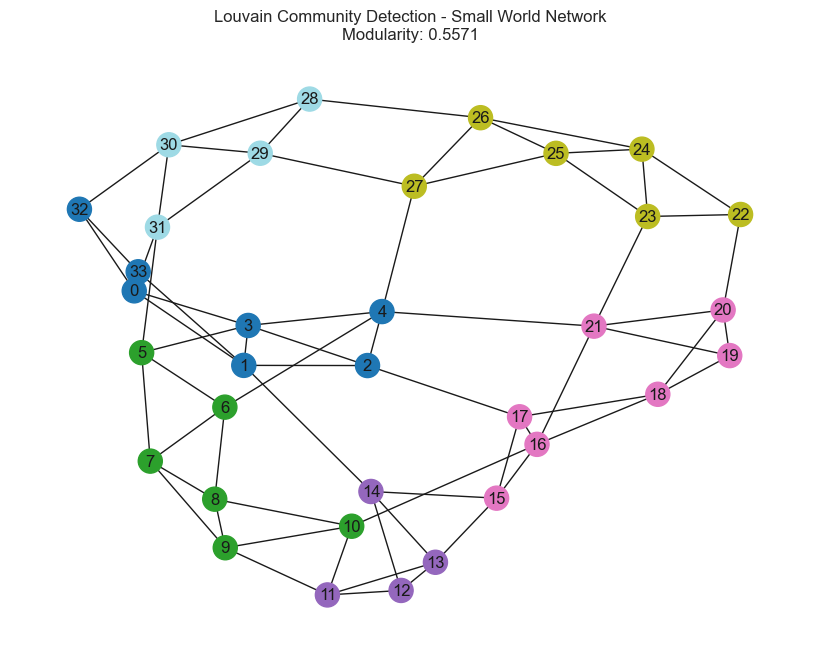

Network: Small World Network
Louvain Modularity: 0.5571
Girvan-Newman Modularity: 0.5004
------------------------------


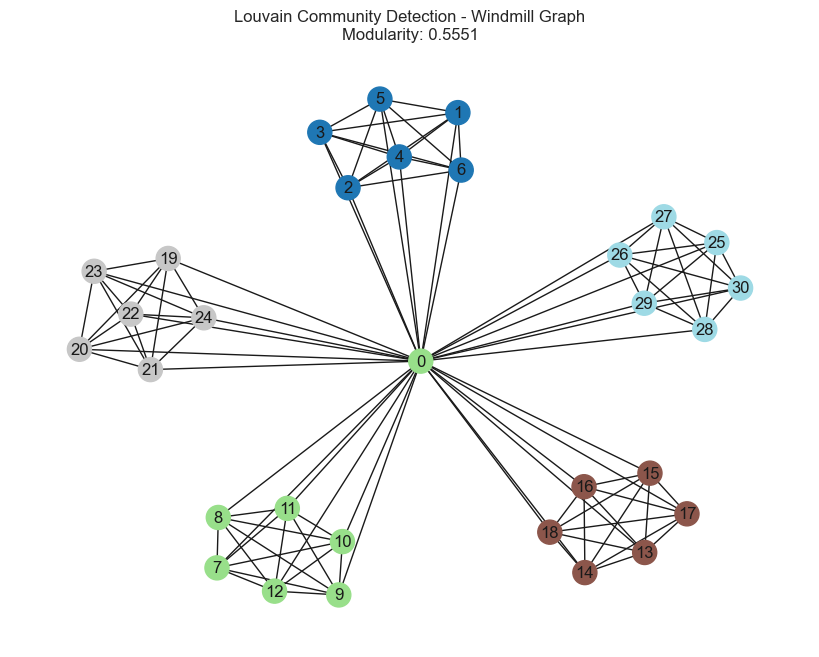

Network: Windmill Graph
Louvain Modularity: 0.5551
Girvan-Newman Modularity: 0.5551
------------------------------


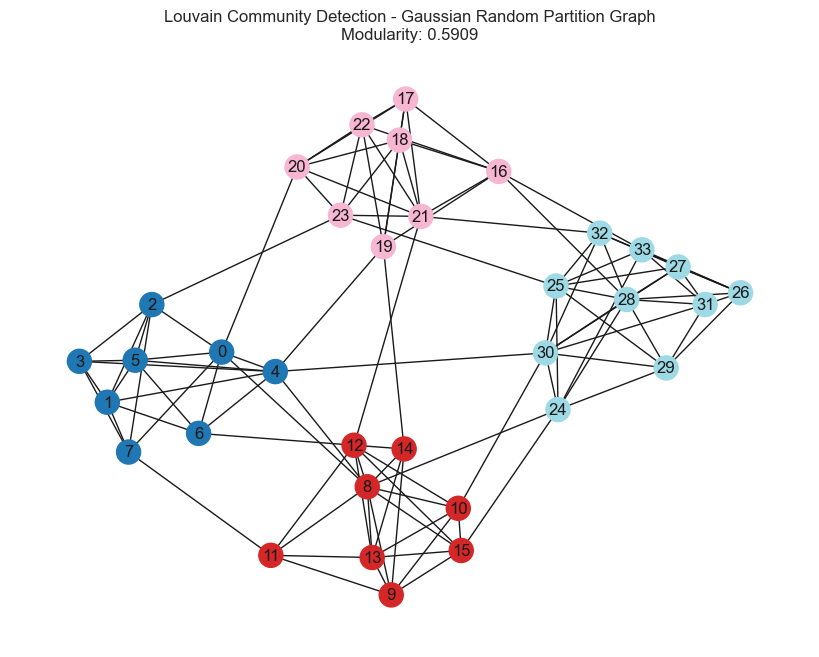

Network: Gaussian Random Partition Graph
Louvain Modularity: 0.5909
Girvan-Newman Modularity: 0.5909
------------------------------


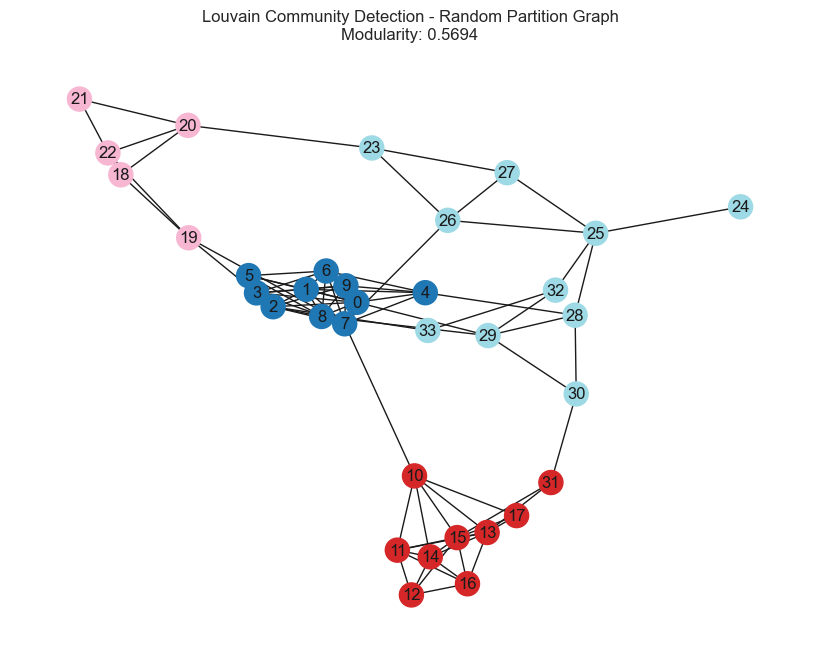

Network: Random Partition Graph
Louvain Modularity: 0.5694
Girvan-Newman Modularity: 0.5641
------------------------------


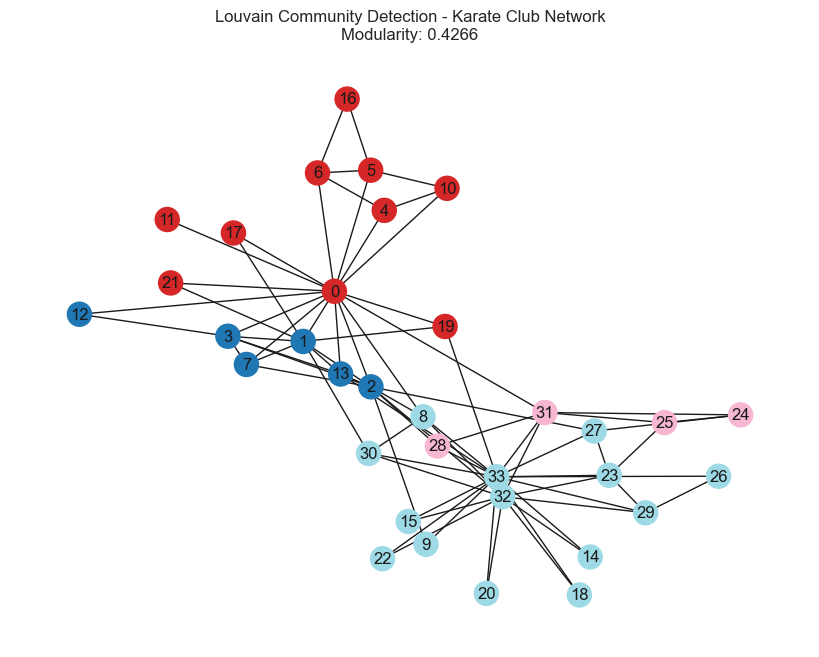

Network: Karate Club Network
Louvain Modularity: 0.4266
Girvan-Newman Modularity: 0.3850
------------------------------


In [64]:
from networkx.algorithms.community import modularity, louvain_communities

louvain_results = {}

for name, graph in graphs.items():
    partition = louvain_communities(graph, seed=42)

    mod_value = modularity(graph, partition)
    louvain_results[name] = mod_value

    node_to_partition = create_node_to_partition_mapping(partition)
    colors = [node_to_partition[n] for n in graph.nodes]

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(graph, seed=42)
    nx.draw(graph, pos, node_color=colors, with_labels=True, cmap=plt.cm.tab20)
    plt.title(f"Louvain Community Detection - {name}\nModularity: {mod_value:.4f}")
    plt.show()

    gn_mod = modularity_results.get(name, 0)
    print(f"Network: {name}")
    print(f"Louvain Modularity: {mod_value:.4f}")
    print(f"Girvan-Newman Modularity: {gn_mod:.4f}")
    print("-" * 30)

#### Conclusions

algorytmy dają bardzo podobne wyniki, Louvian radzi sobie lepiej z nieregularnymi sieciami

## Modularity,  communities and the graph structure

### Task 5
Generate a set of artificial networks of different types (scale-free netowrks, small-world networks, random partition graphs, ...) and with varying properties (size, connectivity, ...).

Study the relationship between network metrics like average centrality measures (degree, betweenness, closeness), clustering coefficient, etc. and modularity value of partition generated with Louvain algorithm as well as number of identified communities.

Analyse and interpret the obtained results, write your conclusions in the cell below.

#### Code

In [75]:
import seaborn as sns
import numpy as np

In [76]:
network_configs = [
    {
        "network": "Scale-free (BA)",
        "parameter": "m",
        "values": [1, 2, 3, 5],
        "builder": lambda v: nx.barabasi_albert_graph(220, v, seed=42),
    },
    {
        "network": "Small-world (WS)",
        "parameter": "rewiring_p",
        "values": [0.01, 0.05, 0.1, 0.3],
        "builder": lambda v: nx.watts_strogatz_graph(220, 6, v, seed=42),
    },
    {
        "network": "Erdos-Renyi (Random)",
        "parameter": "edge_p",
        "values": [0.02, 0.04, 0.06, 0.1],
        "builder": lambda v: nx.erdos_renyi_graph(220, v, seed=42),
    },
    {
        "network": "Random Partition",
        "parameter": "p_in",
        "values": [0.15, 0.25, 0.35, 0.45],
        "builder": lambda v: nx.random_partition_graph(
            [55, 55, 55, 55], v, 0.01, seed=42
        ),
    },
]

rows = []

for config in network_configs:
    for idx, value in enumerate(config["values"], start=1):
        G = config["builder"](value)

        partition = nx.community.louvain_communities(G, seed=42)
        modularity = nx.community.modularity(G, partition)
        num_communities = len(partition)

        avg_degree = np.mean([d for _, d in G.degree()])
        avg_clustering = nx.average_clustering(G)
        avg_betweenness = np.mean(
            list(nx.betweenness_centrality(G, k=40, seed=42).values())
        )
        avg_closeness = np.mean(list(nx.closeness_centrality(G).values()))

        rows.append(
            {
                "Network": config["network"],
                "Parameter": config["parameter"],
                "Value": value,
                "Param Index": idx,
                "Nodes": G.number_of_nodes(),
                "Edges": G.number_of_edges(),
                "Modularity": modularity,
                "Num Communities": num_communities,
                "Avg Degree": avg_degree,
                "Avg Clustering": avg_clustering,
                "Avg Betweenness": avg_betweenness,
                "Avg Closeness": avg_closeness,
            }
        )

df_results = pd.DataFrame(rows)
df_results["Scenario"] = df_results["Parameter"] + "=" + df_results["Value"].astype(str)

print("Porównanie sieci dla różnych parametrów:")
display(df_results.sort_values(["Network", "Param Index"]))

Porównanie sieci dla różnych parametrów:


,Network,Parameter,Value,Param Index,Nodes,Edges,Modularity,Num Communities,Avg Degree,Avg Clustering,Avg Betweenness,Avg Closeness,Scenario
8,Erdos-Renyi (Random),edge_p,0.02,1,220,479,0.470088,13,4.354545,0.015498,0.012577,0.258466,edge_p=0.02
9,Erdos-Renyi (Random),edge_p,0.04,2,220,937,0.304455,10,8.518182,0.034788,0.008086,0.367101,edge_p=0.04
10,Erdos-Renyi (Random),edge_p,0.06,3,220,1420,0.249204,8,12.909091,0.058608,0.006362,0.421097,edge_p=0.06
11,Erdos-Renyi (Random),edge_p,0.10,4,220,2407,0.171524,8,21.881818,0.103281,0.004625,0.499761,edge_p=0.1
12,Random Partition,p_in,0.15,1,220,1095,0.572059,4,9.954545,0.110910,0.008070,0.364952,p_in=0.15
13,Random Partition,p_in,0.25,2,220,1671,0.633858,4,15.190909,0.200611,0.007004,0.397969,p_in=0.25
14,Random Partition,p_in,0.35,3,220,2290,0.665243,4,20.818182,0.297023,0.006463,0.416903,p_in=0.35
15,Random Partition,p_in,0.45,4,220,2830,0.681406,4,25.727273,0.388411,0.006086,0.431456,p_in=0.45
0,Scale-free (BA),m,1.00,1,220,219,0.830571,15,1.990909,0.000000,0.019293,0.201121,m=1.0
1,Scale-free (BA),m,2.00,2,220,436,0.473085,12,3.963636,0.119780,0.010128,0.311771,m=2.0


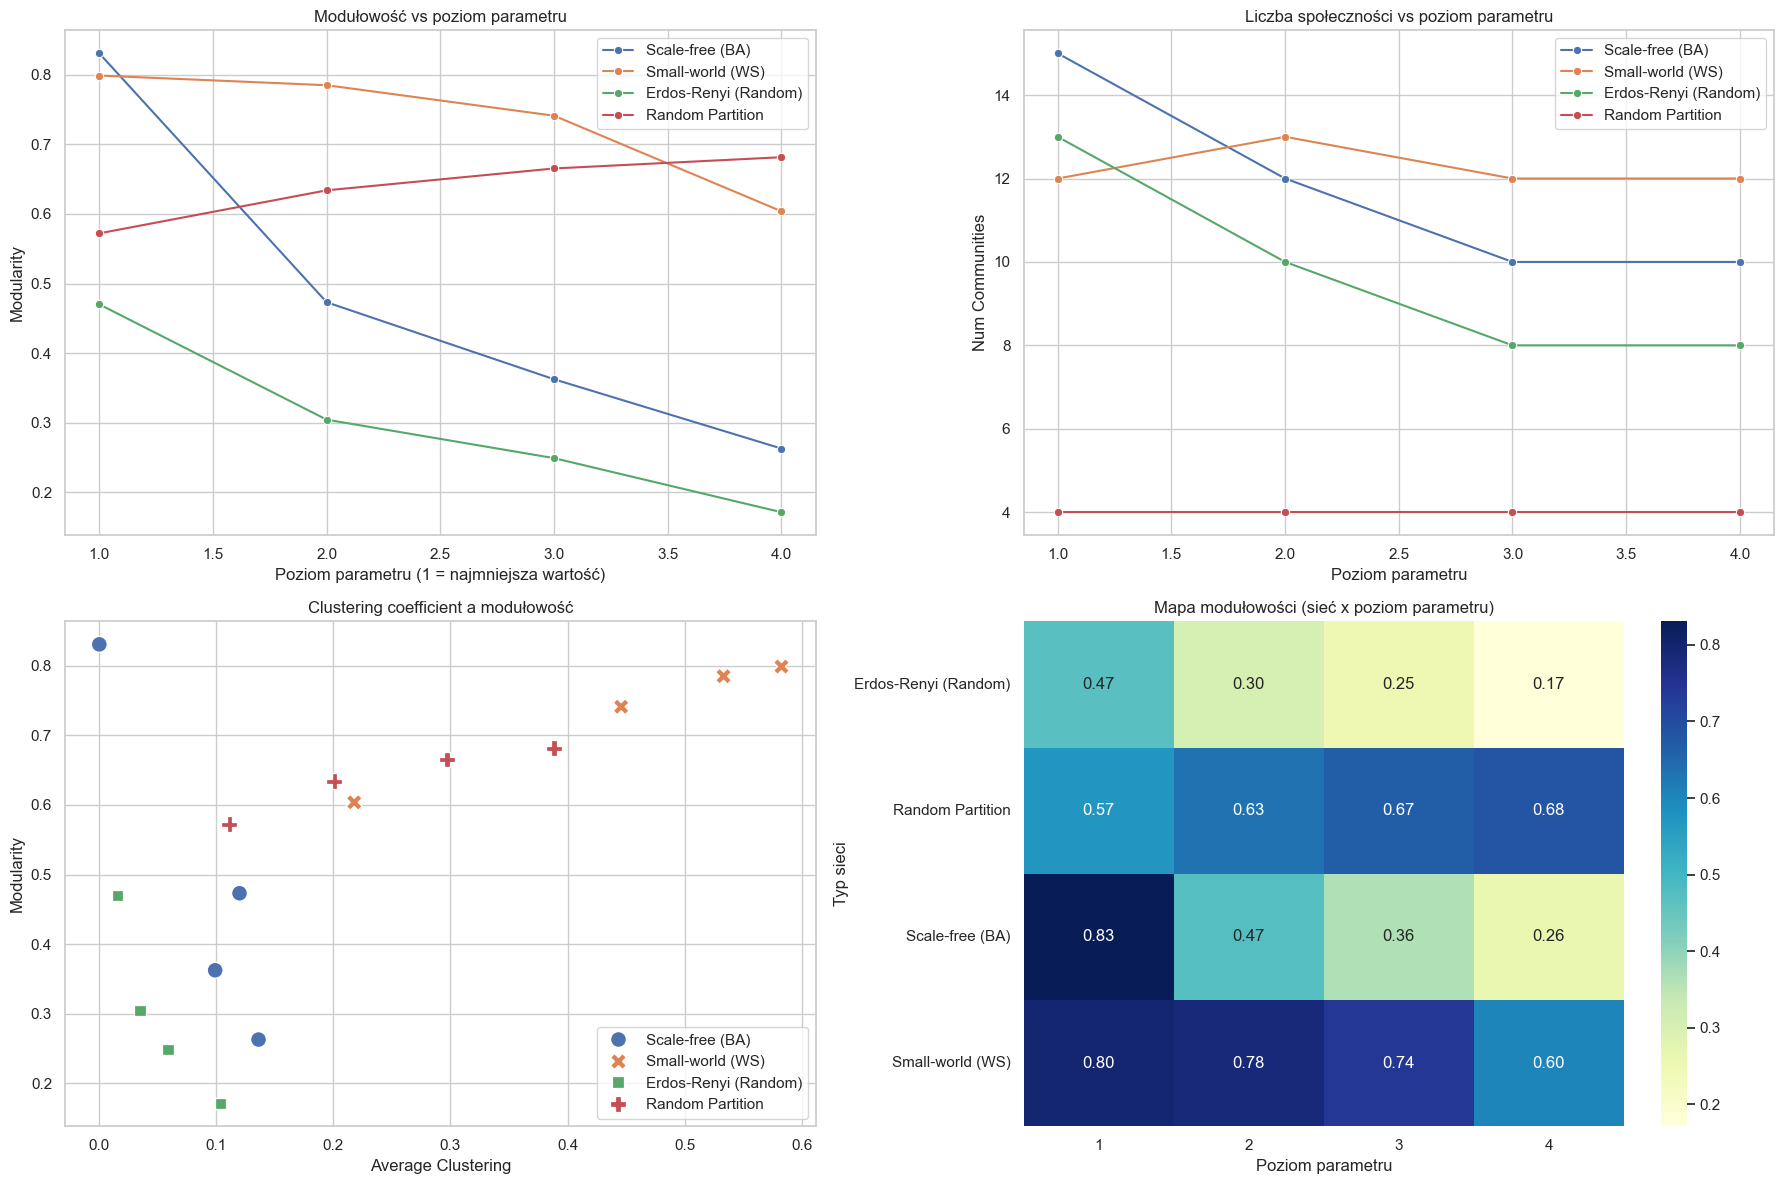

In [77]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.lineplot(
    data=df_results,
    x="Param Index",
    y="Modularity",
    hue="Network",
    marker="o",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Modułowość vs poziom parametru")
axes[0, 0].set_xlabel("Poziom parametru (1 = najmniejsza wartość)")

sns.lineplot(
    data=df_results,
    x="Param Index",
    y="Num Communities",
    hue="Network",
    marker="o",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Liczba społeczności vs poziom parametru")
axes[0, 1].set_xlabel("Poziom parametru")

sns.scatterplot(
    data=df_results,
    x="Avg Clustering",
    y="Modularity",
    hue="Network",
    style="Network",
    s=130,
    ax=axes[1, 0],
)
axes[1, 0].set_title("Clustering coefficient a modułowość")
axes[1, 0].set_xlabel("Average Clustering")

modularity_map = df_results.pivot(
    index="Network", columns="Param Index", values="Modularity"
)
sns.heatmap(
    modularity_map,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Mapa modułowości (sieć x poziom parametru)")
axes[1, 1].set_xlabel("Poziom parametru")
axes[1, 1].set_ylabel("Typ sieci")

for ax in [axes[0, 0], axes[0, 1], axes[1, 0]]:
    ax.legend(loc="best", frameon=True)

plt.tight_layout()
plt.show()

#### Conclusions

## Real world data use-case
The data is a history of internal e-mail communication (`sender, recipient, datetime`) between employees of a mid-sized manufacturing company. Multiple recipients of the same e-mail (`To, CC, BCC`) are represented as separate rows without distinguishing the recipient type. The period covered are nine full months (event dates in local time). The file containing the communication events is named `communication.csv`.

Apart from the communication, information about who in the company reports to whom is attached (`reportsto.csv`). Node #86 is CEO.

### Data preparation

In [67]:
!apt install libgraphviz-dev
!pip install pygraphviz

zsh:1: command not found: apt


Load raw events data

In [68]:
import requests
from pathlib import Path

data_file = Path("communication.tab")
if not data_file.exists():
    r = requests.get(
        "https://dataverse.harvard.edu/api/access/datafile/:persistentId?persistentId=doi:10.7910/DVN/6Z3CGX/KWTRDM"
    )
    with open(data_file, "w") as file:
        file.write(r.text.replace('"', ""))

# alternatively download from:
# https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/6Z3CGX#

raw_df = pd.read_table(data_file, sep=";", header=0, parse_dates=["EventDate"])

Load company hierarchy

In [69]:
data_file = Path("reportsto.tab")
if not data_file.exists():
    r = requests.get(
        "https://dataverse.harvard.edu/api/access/datafile/:persistentId?persistentId=doi:10.7910/DVN/6Z3CGX/SMALXX"
    )
    with open(data_file, "w") as file:
        file.write(r.text.replace('"', ""))

# alternatively download from:
# https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/6Z3CGX#

reportsto = pd.read_csv(data_file, sep=";")

Clean dataset

In [70]:
non_employee_accounts = reportsto[
    reportsto.ReportsToID.apply(lambda x: not x.isnumeric())
]
rows_to_remove = raw_df.loc[
    raw_df["Sender"].isin(non_employee_accounts["ID"])
    | raw_df["Recipient"].isin(non_employee_accounts["ID"])
]
raw_df = raw_df.drop(rows_to_remove.index)
reportsto = reportsto.drop(non_employee_accounts.index)

Plot company hierarchy

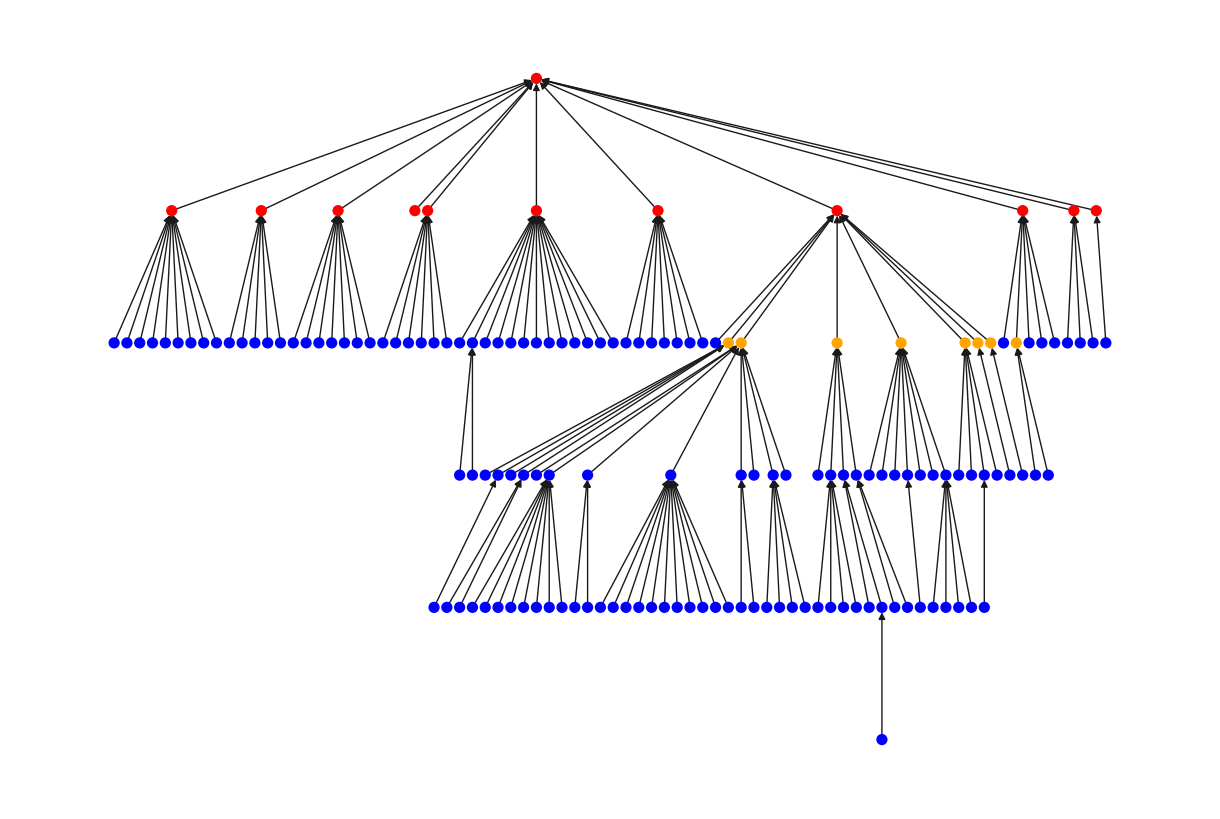

In [71]:
first_management_level = [86, 7, 27, 36, 69, 70, 85, 104, 121, 148, 156, 163]
second_management_level = [76, 90, 136, 137, 143, 152, 47, 162]

H = nx.DiGraph()

for index, row in reportsto.iterrows():
    employee = row["ID"]
    supervisor = int(row["ReportsToID"])
    communication_nodes = set(raw_df["Sender"].values + raw_df["Recipient"].values)
    if employee != supervisor and (
        employee in communication_nodes or supervisor in communication_nodes
    ):
        H.add_edge(employee, supervisor)

color_map = []
for node in H:
    if node in first_management_level:
        color_map.append("red")
    elif node in second_management_level:
        color_map.append("orange")
    else:
        color_map.append("blue")

plt.figure(figsize=(12, 8))
pos_hierarchic = nx.nx_agraph.graphviz_layout(H, prog="dot")
pos_hierarchic = {node: (x, -y) for (node, (x, y)) in pos_hierarchic.items()}
nx.draw(
    H,
    pos=pos_hierarchic,
    with_labels=False,
    arrows=True,
    node_size=50,
    node_color=color_map,
)

plt.show()

### Task 6
Create a weighted network from the communication data (see Section "Data preparation above").
Check if you can find communities in this real world network. Try different algorithms and approaches.

Can weight of the edges be used in that context? What type of graph representation can be an input to the community detection method you use?

Visualize communities using hirarchy positioning defined in the cell above. For the clarity of visualizations, use only edges from hierarchy company structure.

Analyse and interpret the obtained results, write your conclusions in the cell below. Answer the question: How can this kind of network analysis and exploration be leveraged in the company to improve its functioning?

#### Code

In [78]:
edge_df = raw_df[["Sender", "Recipient"]].copy()
edge_df["u"] = edge_df[["Sender", "Recipient"]].min(axis=1)
edge_df["v"] = edge_df[["Sender", "Recipient"]].max(axis=1)
edge_df = edge_df[edge_df["u"] != edge_df["v"]]
weighted_edges = edge_df.groupby(["u", "v"]).size().reset_index(name="weight")

In [79]:
G = nx.Graph()
for _, row in weighted_edges.iterrows():
    G.add_edge(row["u"], row["v"], weight=row["weight"])

lcc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(lcc).copy()

In [81]:
print(f"Liczba wierzchołków w G: {G.number_of_nodes()}")
print(f"Liczba krawędzi w G: {G.number_of_edges()}")

Liczba wierzchołków w G: 153
Liczba krawędzi w G: 3190


In [ ]:
partition_no = nx.community.louvain_communities(G_lcc, weight=None, seed=42)
mod_value_no = nx.community.modularity(G_lcc, partition_no)
print(f"Modularity of the partition: {mod_value_no:.4f}")

Modularity of the partition: 0.2153


In [ ]:
partition_weigths = nx.community.louvain_communities(G_lcc, weight="weight", seed=42)
mod_value_weigths = nx.community.modularity(G_lcc, partition_weigths, weight="weight")
print(f"Modularity of the partition: {mod_value_weigths:.4f}")

Modularity of the partition: 0.3933


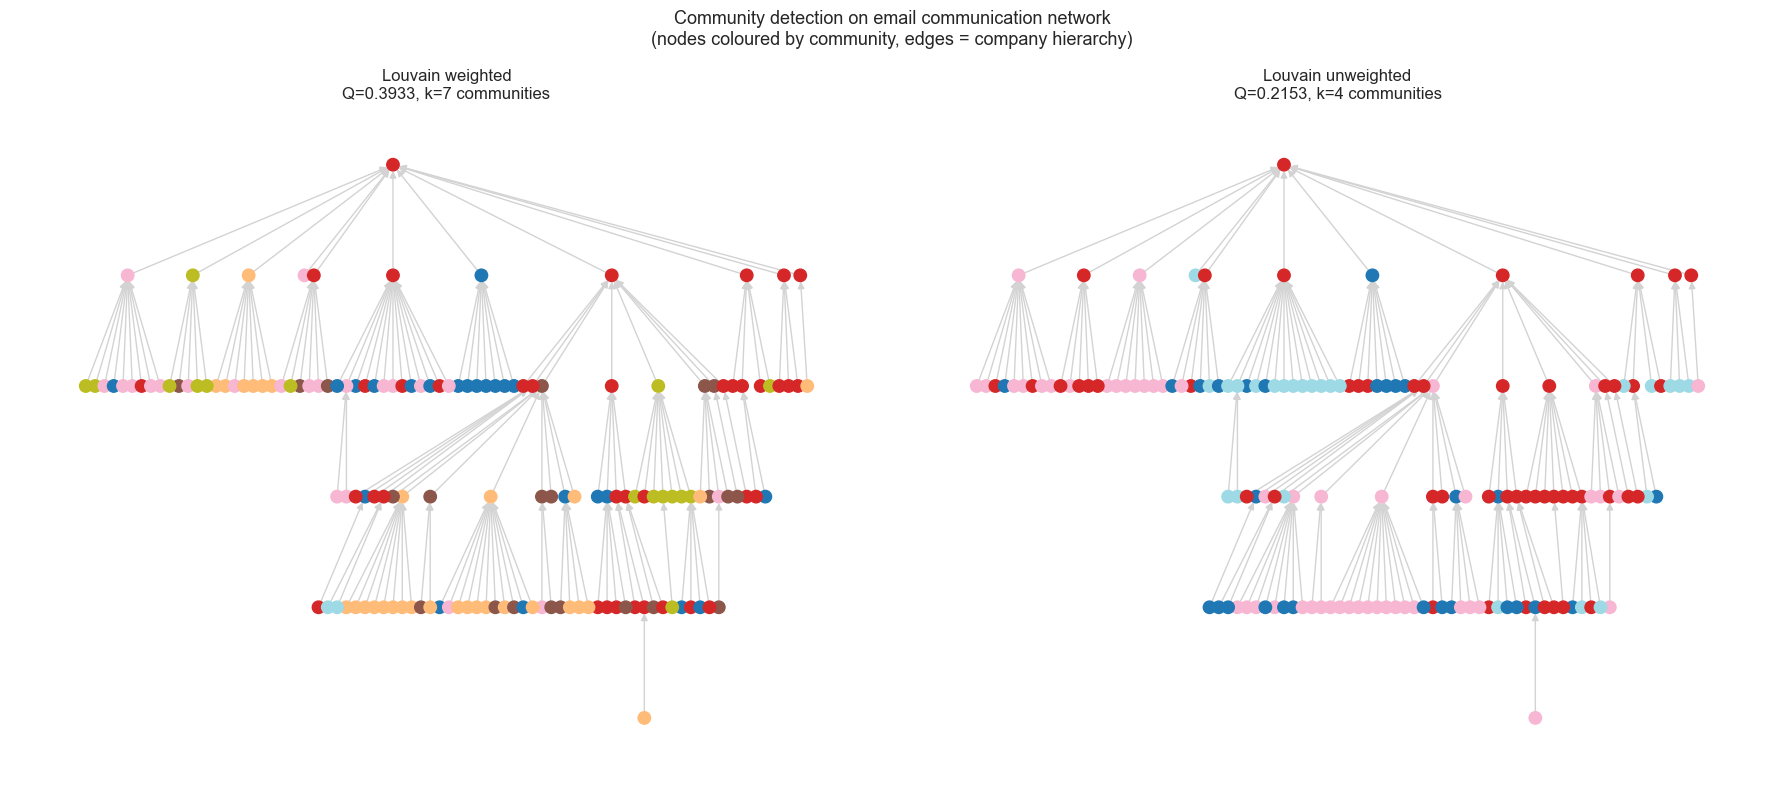

In [100]:
node_to_comm_w = {
    node: idx for idx, comm in enumerate(partition_weigths) for node in comm
}
node_to_comm_uw = {node: idx for idx, comm in enumerate(partition_no) for node in comm}

common_nodes = [n for n in H.nodes() if n in G.nodes()]
H_sub = H.subgraph(common_nodes)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, (label, node_to_comm, q, partition) in zip(
    axes,
    [
        ("Louvain weighted", node_to_comm_w, mod_value_weigths, partition_weigths),
        ("Louvain unweighted", node_to_comm_uw, mod_value_no, partition_no),
    ],
):
    node_colors = [node_to_comm.get(n, -1) for n in H_sub.nodes()]
    pos_sub = {n: pos_hierarchic[n] for n in H_sub.nodes() if n in pos_hierarchic}
    nx.draw(
        H_sub,
        pos=pos_sub,
        ax=ax,
        node_color=node_colors,
        cmap=plt.cm.tab20,
        with_labels=False,
        node_size=80,
        edge_color="lightgray",
        arrows=True,
    )
    ax.set_title(f"{label}\nQ={q:.4f}, k={len(partition)} communities", fontsize=12)

plt.suptitle(
    "Community detection on email communication network\n(nodes coloured by community, edges = company hierarchy)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

#### Conclusions

- Model wazony (po lewej) uwzglednia liczbe maili, tworzyc 7 malych, gestych grup. Model niewazyony (po prawej) ignoruje wolumen, tworzyc 4 duze, luzniejsze bloki.
- Komunikacja ignoruje silosy. Rozproszenie kolorow dowodzi, ze pracownicy wspolpracuja poza oficjalnymi liniami raportowania.
